# Notebook for Unsupervised ML: Detecting conservation laws

Validated version with two post-hoc physics checks.

- Code taken and adapted from: https://github.com/KindXiaoming/aipoincare/blob/master/backend/training.py
- Dataset from: https://github.com/KindXiaoming/aipoincare/blob/master/backend/data/oned_harmonic
- ChatGPT assistance (30 Sept 2025 and 5 May 2026)

## Set up working tree and load packages

In [2]:
# --------------------- Import necessary libraries ---------------------
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import os
from sklearn.decomposition import PCA
import torch.optim as optim
import copy

# set seeds to make outputs reproducible
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

In [3]:
# --------------------- Set hyperparameters and data config ---------------------

# Hidden layer widths for the neural network; first and last layer are added later
nn_widths = [256, 256]  # Two hidden layers: 64 units and 32 units
hidden_depth = len(nn_widths)
# Negative slope for LeakyReLU activation function
slope = 0.1
# List of noise magnitudes (sigmal) to test during training
sigmals = [1e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0, 10.0]
# Optimizer type: 'Adam' or 'SGD'
opt = 'Adam'
# Learning rate for optimizer
lr = 0.001
# Mini-batch size for training
batch_size = 64
# Number of training iterations (epochs)
epoch = 5000
# ERD parameter `a` for computing effective dimensionality
a = 2
# Path to the input data file (must be a .txt file of shape [n_samples, n_features])
model = 'harmonic_1d.txt'
# Number of random walks to simulate for post-training variance analysis
n_walk = 600

[[ 0.          1.        ]
 [ 1.          0.95      ]
 [ 1.9         0.805     ]
 ...
 [ 2.0462222  -0.7692627 ]
 [ 1.1746484  -0.9303062 ]
 [ 0.18560985 -0.9983191 ]] 1000 2


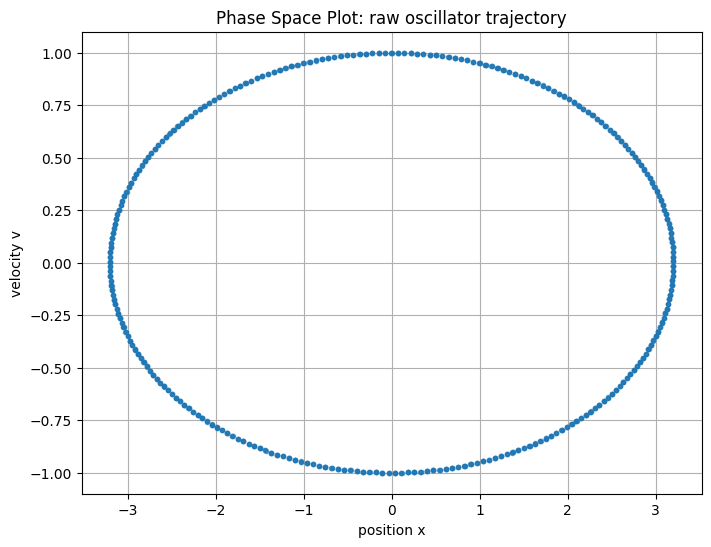

In [4]:
# --------------------- Load and preprocess the data ---------------------

# Load dataset as NumPy array.
# The raw coordinates are kept for the physics validation at the end of the notebook.
xs_raw = np.loadtxt(model).astype(np.float32)
xs = xs_raw.copy()

n_train = xs.shape[0]       # Number of samples
input_dim = xs.shape[1]     # Dimensionality of input features

# Show data set and plot phase space
print(xs_raw, n_train, input_dim)

plt.figure(figsize=(8, 6))
plt.plot(xs_raw[:, 0], xs_raw[:, 1], '.', alpha=0.6)
plt.title("Phase Space Plot: raw oscillator trajectory")
plt.xlabel("position x")
plt.ylabel("velocity v")
plt.grid(True)
plt.show()

In [5]:
# Step 1: Normalize each input feature to zero mean and unit variance.
# We store mean and standard deviation so that validation points can later be
# transformed back to physical coordinates.
raw_mean = xs_raw.mean(axis=0)
raw_std = xs_raw.std(axis=0)
raw_std[raw_std == 0] = 1.0

xs = (xs_raw - raw_mean[np.newaxis, :]) / raw_std[np.newaxis, :]

# Sanity check that mean = 0, and std = 1
np.round(xs.mean(axis=0), 3), np.round(xs.std(axis=0), 3)

(array([-0.,  0.], dtype=float32), array([1., 1.], dtype=float32))

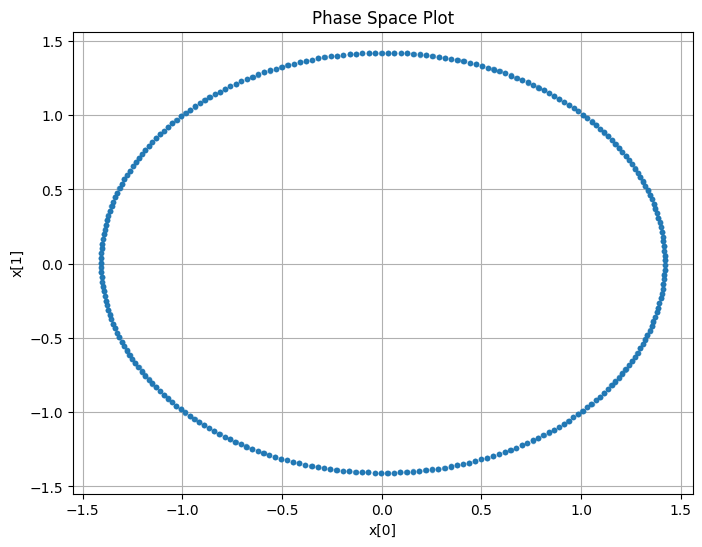

In [6]:
# Step 2: Apply PCA (rotation only, no scaling) to decorrelate dimensions
pca = PCA()
xs = pca.fit_transform(xs)

# Plot transformed data
plt.figure(figsize=(8, 6))
plt.plot(xs[:, 0], xs[:, 1], '.', alpha=0.6)
plt.title("Phase Space Plot")
plt.xlabel("x[0]")
plt.ylabel("x[1]")
plt.grid(True)
plt.show()

In [7]:
# Build the entire hidden dimensions of the NN:
nn_widths.insert(0, input_dim)
nn_widths.append(input_dim)
print( nn_widths )

[2, 256, 256, 2]


## Training

In [8]:
# --------------------- Training loop across different noise levels ---------------------
exps = []   # To store explained variance ratios
losses = [] # To record loss values during training

for sigmal in sigmals:
    # Define a new neural network (as a list of layers) for each noise level
    linears = [nn.Linear(nn_widths[i], nn_widths[i + 1]) for i in range(hidden_depth + 1)]
    parameters = [p for layer in linears for p in layer.parameters()]  # Collect all trainable parameters

    # Define loss function
    criterion = nn.MSELoss()

    # Choose optimizer
    optimizer = optim.Adam(parameters, lr=lr) if opt == "Adam" else optim.SGD(parameters, lr=lr)

    print(f"sigmal = {sigmal}")

    # --------------------- Training the denoising network ---------------------
    # (see in the Appendix below a step by step explanation of these steps)
    
    for j in range(epoch):
        # Randomly sample a batch of training data
        choices = np.random.choice(n_train, batch_size)
        perturb = torch.normal(0, sigmal, size=(batch_size, input_dim))  # Add Gaussian noise
        inputs0 = torch.tensor(xs[choices], dtype=torch.float) + perturb  # Noisy input

        # Forward pass through each layer using LeakyReLU
        x = inputs0
        act = nn.LeakyReLU(slope)
        for i in range(hidden_depth):
            x = act(linears[i](x))
        outputs = linears[hidden_depth](x)  # Final layer (no activation)

        # Training objective: recover the *negative* of the noise added
        loss = criterion(outputs, -perturb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(float(loss.data))

        if j % 200 == 0:
            print(f"Epoch {j} | Loss: {loss:.4f}")

    # --------------------- Perform stochastic walks using trained network ---------------------
    x0 = copy.deepcopy(xs[int(n_train / 2)])  # Start from a central data point
    x0 = x0[np.newaxis, :]
    x0 = x0 + np.random.randn(n_walk, input_dim) * sigmal  # Add noise

    # Pass walk samples through trained denoising network
    x = torch.tensor(x0, dtype=torch.float)
    for i in range(hidden_depth):
        x = act(linears[i](x))
    x = linears[hidden_depth](x)
    x0 = x0 + x.detach().numpy()  # Apply learned correction

    # --------------------- Compute explained variance ratio via PCA ---------------------
    pca = PCA()
    pca.fit(x0)
    svs = pca.singular_values_
    exp_ratio = svs**2 / np.sum(svs**2)
    exps.append(exp_ratio)

# Stack results into a NumPy array
exps = np.array(exps)

sigmal = 0.001
Epoch 0 | Loss: 0.0208
Epoch 200 | Loss: 0.0000
Epoch 400 | Loss: 0.0000
Epoch 600 | Loss: 0.0000
Epoch 800 | Loss: 0.0000
Epoch 1000 | Loss: 0.0000
Epoch 1200 | Loss: 0.0000
Epoch 1400 | Loss: 0.0000
Epoch 1600 | Loss: 0.0000
Epoch 1800 | Loss: 0.0001
Epoch 2000 | Loss: 0.0000
Epoch 2200 | Loss: 0.0000
Epoch 2400 | Loss: 0.0000
Epoch 2600 | Loss: 0.0000
Epoch 2800 | Loss: 0.0000
Epoch 3000 | Loss: 0.0000
Epoch 3200 | Loss: 0.0000
Epoch 3400 | Loss: 0.0000
Epoch 3600 | Loss: 0.0000
Epoch 3800 | Loss: 0.0000
Epoch 4000 | Loss: 0.0000
Epoch 4200 | Loss: 0.0000
Epoch 4400 | Loss: 0.0000
Epoch 4600 | Loss: 0.0000
Epoch 4800 | Loss: 0.0000
sigmal = 0.01
Epoch 0 | Loss: 0.0064
Epoch 200 | Loss: 0.0001
Epoch 400 | Loss: 0.0002
Epoch 600 | Loss: 0.0001
Epoch 800 | Loss: 0.0001
Epoch 1000 | Loss: 0.0001
Epoch 1200 | Loss: 0.0001
Epoch 1400 | Loss: 0.0001
Epoch 1600 | Loss: 0.0001
Epoch 1800 | Loss: 0.0001
Epoch 2000 | Loss: 0.0001
Epoch 2200 | Loss: 0.0001
Epoch 2400 | Loss: 0.00

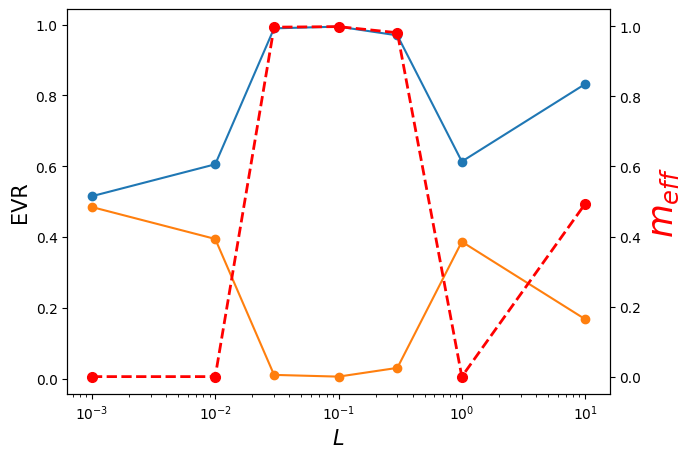

<Figure size 640x480 with 0 Axes>

In [9]:
# --------------------- Define helper function to compute effective rank (ERD) ---------------------
def f(x, a=2):
    n = x.shape[1]
    mask = x < 1 / (a * n)
    return np.sum(np.cos(np.pi / 2 * n * a * x) * mask, axis=1)

# --------------------- Plot explained variance and effective dimensionality ---------------------
plt.figure(figsize=(7, 5))

# Plot each PCA component’s explained variance
for i in range(input_dim):
    plt.plot(sigmals, exps[:, i], marker="o")

plt.xscale('log')
plt.xlabel(r"$L$", fontsize=15)
plt.ylabel("EVR", fontsize=15)

# Plot effective dimensionality (ERD) on second y-axis
ax2 = plt.gca().twinx()
ax2.plot(sigmals, f(exps, a=2), marker="o", color="red", linewidth=2, ls="--", markersize=7)
plt.ylabel(r"$m_{eff}$", fontsize=25, color="red")

# Save the plot to disk
plt.savefig('ERD.png', bbox_inches="tight")

plt.show()
plt.clf()

In [10]:
# Define a new neural network (as a list of layers) for each noise level
linears = [nn.Linear(nn_widths[i], nn_widths[i + 1]) for i in range(hidden_depth + 1)]
parameters = [p for layer in linears for p in layer.parameters()]  # Collect all trainable parameters

# Define loss function
criterion = nn.MSELoss()

# Choose optimizer
optimizer = optim.Adam(parameters, lr=lr) if opt == "Adam" else optim.SGD(parameters, lr=lr)

sigmal = .1
epoch = 1000

# --------------------- Training the denoising network ---------------------
# (see in the Appendix below a step by step explanation of these steps)

for j in range(epoch):
    # Randomly sample a batch of training data
    choices = np.random.choice(n_train, batch_size)
    perturb = torch.normal(0, sigmal, size=(batch_size, input_dim))  # Add Gaussian noise
    inputs0 = torch.tensor(xs[choices], dtype=torch.float) + perturb  # Noisy input

    # Forward pass through each layer using LeakyReLU
    x = inputs0
    act = nn.LeakyReLU(slope)
    for i in range(hidden_depth):
        x = act(linears[i](x))
    outputs = linears[hidden_depth](x)  # Final layer (no activation)

    # Training objective: recover the *negative* of the noise added
    loss = criterion(outputs, -perturb)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if j % 200 == 0:
        print(f"Epoch {j} | Loss: {loss:.4f}")

Epoch 0 | Loss: 0.0108
Epoch 200 | Loss: 0.0046
Epoch 400 | Loss: 0.0055
Epoch 600 | Loss: 0.0044
Epoch 800 | Loss: 0.0050


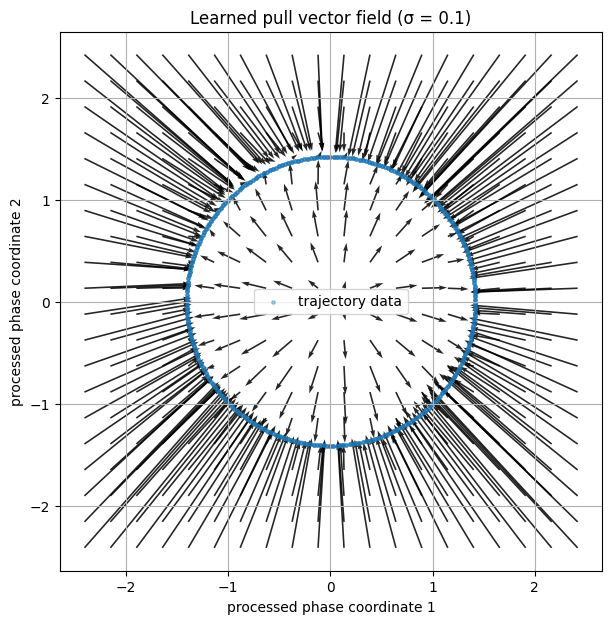

Saved: img/vector_field.png


In [11]:
# --------------------- Vector-field visualization ---------------------
# Only do vector field visualization for 2D input.
# The arrows show the correction predicted by the trained pull network.
# The trajectory points are overlaid so that one can see whether the learned
# corrections point back toward the one-dimensional oscillator manifold.

os.makedirs("img", exist_ok=True)

# Create a 2D grid of points over the range of training data
# Here xs is the normalized/PCA-transformed phase-space representation used for training.
grid_size = 20
x_min, x_max = xs[:, 0].min() - 1, xs[:, 0].max() + 1
y_min, y_max = xs[:, 1].min() - 1, xs[:, 1].max() + 1
x_vals = np.linspace(x_min, x_max, grid_size)
y_vals = np.linspace(y_min, y_max, grid_size)
xv, yv = np.meshgrid(x_vals, y_vals)
grid_points = np.stack([xv.ravel(), yv.ravel()], axis=1)

# Pass grid points through network to get denoising vectors
with torch.no_grad():
    inputs = torch.tensor(grid_points, dtype=torch.float)
    x = inputs.clone()
    for i in range(hidden_depth):
        x = act(linears[i](x))
    outputs = linears[hidden_depth](x)

    # The output is the estimated negative noise: it shows how the network
    # would move a perturbed state back toward the learned trajectory manifold.
    vectors = outputs.numpy()

# Plot vector field and trajectory
plt.figure(figsize=(7, 7))
plt.quiver(
    grid_points[:, 0], grid_points[:, 1],
    vectors[:, 0], vectors[:, 1],
    angles='xy', scale_units='xy', scale=1,
    width=0.003, alpha=0.85
)
plt.scatter(xs[:, 0], xs[:, 1], s=6, alpha=0.35, label="trajectory data")
plt.title(f"Learned pull vector field (σ = {sigmal})")
plt.xlabel("processed phase coordinate 1")
plt.ylabel("processed phase coordinate 2")
plt.axis("equal")
plt.grid(True)
plt.legend(loc="best")

# Save to file for the manuscript
plt.savefig("img/vector_field.png", dpi=300, bbox_inches="tight")
plt.savefig("vector_field.png", dpi=300, bbox_inches="tight")

# Show on screen
plt.show()
print("Saved: img/vector_field.png")

## Quantitative validation

The vector-field plot gives an intuitive picture, but it should not be treated as proof of a conservation law. The following two post-hoc validations ask whether the trained pull network has learned the expected physics of the undamped harmonic oscillator.

1. **Intrinsic-dimension validation:** after noisy points are pulled back by the network, local point clouds should become approximately one-dimensional, because a fixed-energy oscillator trajectory is an ellipse.
2. **Energy-consistency validation:** although energy was not used during training, corrected points should lie closer to the constant-energy curve than the noisy inputs.

These tests use physics only after training. They evaluate the learned representation; they do not supervise the network.

In [12]:
# --------------------- Validation helper functions ---------------------
# These functions reuse the trained pull network from the vector-field cell.

from sklearn.decomposition import PCA

# Oscillator parameters used only for post-hoc physics validation.
# If your data were generated with different values, change these two numbers.
m = 1.0
c = 1.0


def pull_vectors(points_processed):
    """Return the pull-network correction vectors for processed coordinates."""
    with torch.no_grad():
        t = torch.tensor(points_processed, dtype=torch.float)
        y = t.clone()
        for layer_idx in range(hidden_depth):
            y = act(linears[layer_idx](y))
        y = linears[hidden_depth](y)
    return y.detach().cpu().numpy()


def pull_back(points_processed):
    """Apply the learned correction to processed coordinates."""
    return points_processed + pull_vectors(points_processed)


def inverse_preprocess(points_processed):
    """Map processed coordinates back to the raw phase-space coordinates."""
    points_norm = pca.inverse_transform(points_processed)
    return points_norm * raw_std[np.newaxis, :] + raw_mean[np.newaxis, :]


def oscillator_energy(points_raw):
    """Mechanical energy H = 1/2 m v^2 + 1/2 c x^2 for raw coordinates."""
    x = points_raw[:, 0]
    v = points_raw[:, 1]
    return 0.5 * m * v**2 + 0.5 * c * x**2

# Reference energy of the clean trajectory. Median is robust to small numerical noise.
E0 = np.median(oscillator_energy(xs_raw))
print(f"Reference trajectory energy E0 ≈ {E0:.6f}")

Reference trajectory energy E0 ≈ 2.803726


### Validation 1: local intrinsic dimension after pullback

For each selected trajectory point, the code samples a small cloud of nearby noisy points, applies the trained pull network, and performs PCA on the corrected cloud. If the network has learned the one-dimensional oscillator trajectory, the first principal direction should explain almost all remaining variance. The reported participation-ratio dimension is close to 1 for a line-like cloud and close to 2 for an area-like cloud.

In [13]:
# --------------------- Procedure 1: intrinsic-dimension validation ---------------------
rng = np.random.default_rng(seed)

n_centers = min(80, n_train)
n_local = 200
validation_noise = sigmal  # use the same scale as the final trained vector-field model

center_indices = rng.choice(n_train, size=n_centers, replace=False)
local_dims_pr = []
local_dims_95 = []
first_pc_ratios = []

for idx in center_indices:
    center = xs[idx:idx+1]
    noisy_cloud = center + rng.normal(0.0, validation_noise, size=(n_local, input_dim))
    pulled_cloud = pull_back(noisy_cloud)

    pca_local = PCA(n_components=input_dim)
    pca_local.fit(pulled_cloud)
    evr = pca_local.explained_variance_ratio_

    # Participation-ratio dimension: 1/sum(EVR_i^2).
    # For a nearly one-dimensional cloud this is close to 1.
    pr_dim = 1.0 / np.sum(evr**2)

    # Number of PCs needed to explain 95% of the variance.
    dim95 = int(np.searchsorted(np.cumsum(evr), 0.95) + 1)

    local_dims_pr.append(pr_dim)
    local_dims_95.append(dim95)
    first_pc_ratios.append(evr[0])

local_dims_pr = np.asarray(local_dims_pr)
local_dims_95 = np.asarray(local_dims_95)
first_pc_ratios = np.asarray(first_pc_ratios)

print("Procedure 1: local intrinsic-dimension validation")
print(f"  Mean participation-ratio dimension: {local_dims_pr.mean():.3f} ± {local_dims_pr.std():.3f}")
print(f"  Median number of PCs for 95% variance: {np.median(local_dims_95):.0f}")
print(f"  Mean variance explained by first PC: {first_pc_ratios.mean():.3f} ± {first_pc_ratios.std():.3f}")

if local_dims_pr.mean() < 1.25 and first_pc_ratios.mean() > 0.90:
    print("  Interpretation: strong evidence for an approximately one-dimensional learned manifold.")
elif local_dims_pr.mean() < 1.50 and first_pc_ratios.mean() > 0.75:
    print("  Interpretation: moderate evidence for dimensionality reduction, but the manifold is not very sharply recovered.")
else:
    print("  Interpretation: weak evidence; the pullback clouds remain too area-like to support a clear 1-D manifold claim.")

Procedure 1: local intrinsic-dimension validation
  Mean participation-ratio dimension: 1.019 ± 0.013
  Median number of PCs for 95% variance: 1
  Mean variance explained by first PC: 0.990 ± 0.006
  Interpretation: strong evidence for an approximately one-dimensional learned manifold.


### Validation 2: energy consistency of corrected states

The pull network was trained only to remove artificial noise in phase space. It was not given the Hamiltonian. Therefore, a useful physics validation is to ask whether the corrected points are closer to the constant-energy curve than the noisy inputs. The diagnostic below compares the average absolute energy error before and after pullback. It also checks whether the learned correction direction is aligned with the expected normal direction to the energy contour.

Procedure 2: energy-consistency validation
  Mean |H(noisy) - E0|:     1.525709e+00
  Mean |H(corrected) - E0|: 1.534199e+00
  Relative energy-error reduction: -0.006
  Mean correction/energy-normal alignment: 0.036 ± 0.898
  Interpretation: weak evidence; the correction field should not yet be interpreted as a reliable energy-manifold projection.


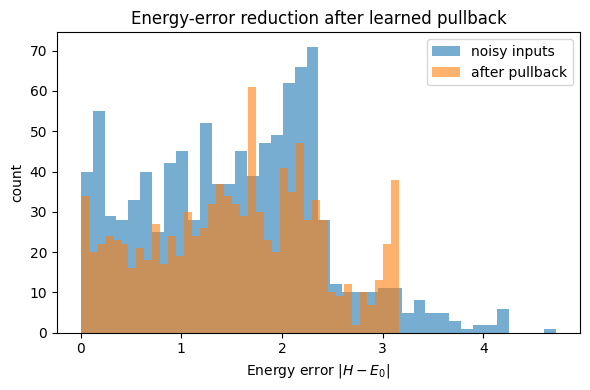

Saved: img/energy_error_validation.png


In [14]:
# --------------------- Procedure 2: energy-consistency validation ---------------------
n_val = min(2000, n_train)
val_indices = rng.choice(n_train, size=n_val, replace=False)

clean_processed = xs[val_indices]
noisy_processed = clean_processed + rng.normal(0.0, validation_noise, size=clean_processed.shape)
corrected_processed = pull_back(noisy_processed)

noisy_raw = inverse_preprocess(noisy_processed)
corrected_raw = inverse_preprocess(corrected_processed)

H_noisy = oscillator_energy(noisy_raw)
H_corrected = oscillator_energy(corrected_raw)

energy_error_noisy = np.abs(H_noisy - E0)
energy_error_corrected = np.abs(H_corrected - E0)

energy_error_reduction = 1.0 - energy_error_corrected.mean() / energy_error_noisy.mean()

# Directional check: the correction should point approximately toward the energy contour.
# If the noisy point is outside the contour, the correction should oppose grad(H).
# If it is inside the contour, it should point along grad(H).
correction_raw = corrected_raw - noisy_raw
gradH = np.column_stack([c * noisy_raw[:, 0], m * noisy_raw[:, 1]])
target_direction = -np.sign(H_noisy - E0)[:, None] * gradH

norm_corr = np.linalg.norm(correction_raw, axis=1)
norm_target = np.linalg.norm(target_direction, axis=1)
valid = (norm_corr > 1e-12) & (norm_target > 1e-12) & (energy_error_noisy > np.percentile(energy_error_noisy, 10))
cos_alignment = np.sum(correction_raw[valid] * target_direction[valid], axis=1) / (norm_corr[valid] * norm_target[valid])

print("Procedure 2: energy-consistency validation")
print(f"  Mean |H(noisy) - E0|:     {energy_error_noisy.mean():.6e}")
print(f"  Mean |H(corrected) - E0|: {energy_error_corrected.mean():.6e}")
print(f"  Relative energy-error reduction: {energy_error_reduction:.3f}")
print(f"  Mean correction/energy-normal alignment: {cos_alignment.mean():.3f} ± {cos_alignment.std():.3f}")

if energy_error_reduction > 0.70 and cos_alignment.mean() > 0.70:
    print("  Interpretation: strong evidence that the learned pull field is consistent with the constant-energy manifold.")
elif energy_error_reduction > 0.40 and cos_alignment.mean() > 0.40:
    print("  Interpretation: moderate evidence; the network improves energy consistency, but the learned field is imperfect.")
else:
    print("  Interpretation: weak evidence; the correction field should not yet be interpreted as a reliable energy-manifold projection.")

# Optional compact visualization for the notebook
plt.figure(figsize=(6, 4))
plt.hist(energy_error_noisy, bins=40, alpha=0.6, label="noisy inputs")
plt.hist(energy_error_corrected, bins=40, alpha=0.6, label="after pullback")
plt.xlabel(r"Energy error $|H - E_0|$")
plt.ylabel("count")
plt.title("Energy-error reduction after learned pullback")
plt.legend()
plt.tight_layout()
plt.savefig("img/energy_error_validation.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: img/energy_error_validation.png")

### More details on ANN processing

In [17]:
sigmal = 0.1

# Define a new neural network (as a list of layers) for each noise level
linears = [nn.Linear(nn_widths[i], nn_widths[i + 1]) for i in range(hidden_depth + 1)]
parameters = [p for layer in linears for p in layer.parameters()]  # Collect all trainable parameters

In [18]:
# Display parameter structure of ANN:
linears

[Linear(in_features=2, out_features=256, bias=True),
 Linear(in_features=256, out_features=256, bias=True),
 Linear(in_features=256, out_features=2, bias=True)]

In [25]:
# Define loss function
criterion = nn.MSELoss()

# Choose optimizer
optimizer = optim.Adam(parameters, lr=lr) if opt == "Adam" else optim.SGD(parameters, lr=lr)

print(f"sigmal = {sigmal}")

sigmal = 0.1


In [26]:
# --------------------- Training the denoising network ---------------------
# Randomly sample a batch of training data
choices = np.random.choice(n_train, batch_size)
perturb = torch.normal(0, sigmal, size=(batch_size, input_dim))  # Add Gaussian noise
inputs0 = torch.tensor(xs[choices], dtype=torch.float) + perturb  # Noisy input

print( f"Random indices: {choices}")
print( f"Mean of perturbation: {torch.mean(perturb,axis=0)}")
print( f"Std of perturbation: {torch.std(perturb,axis=0)}")

Random indices: [969 582 105 420 769 881 863 440 401  86  81 850 591 169 128 654 714 234
  48 174 785 873  66 543 529 672 496   9 478 151 891 345 793  30 418 115
 360 205 969 580 333 998  30 670 890 624 662  99  56 313 297 676 149 632
 649 204 907 375 499 545  96 957 659 792]
Mean of perturbation: tensor([ 0.0122, -0.0164])
Std of perturbation: tensor([0.0973, 0.0992])


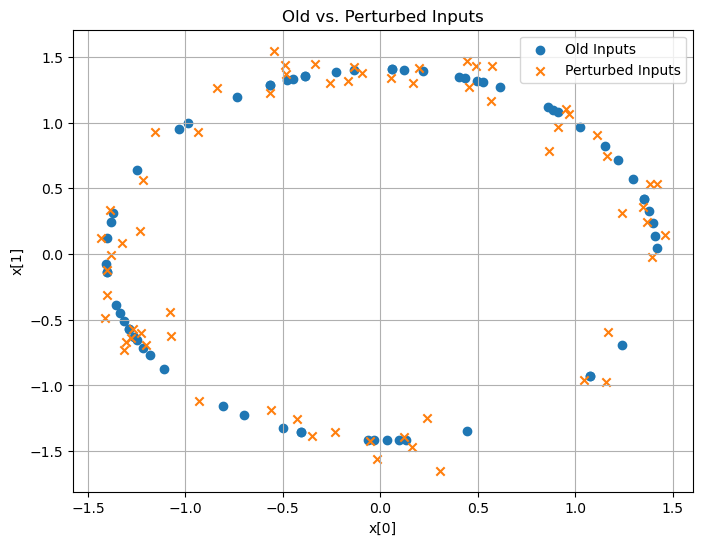

In [178]:
# Plot
plt.figure(figsize=(8, 6))
plt.scatter(xs[choices][:, 0], xs[choices][:, 1], label='Old Inputs', marker='o')
plt.scatter(inputs0[:, 0], inputs0[:, 1], label='Perturbed Inputs', marker='x')
plt.title("Old vs. Perturbed Inputs")
plt.xlabel("x[0]")
plt.ylabel("x[1]")
plt.legend()
plt.grid(True)
plt.show()

LeakyReLU (activation function) allows for $x<0$ small gradients according to:
$f(x) = 
\begin{cases}
x & \text{if } x > 0 \\
\text{slope} \cdot x & \text{if } x \leq 0
\end{cases}$

In the following, linear transformations with non-linear activation (LeakyReLU), $\sigma$ are applied:
$x \rightarrow \sigma( Wx + b ) $

In [199]:
# Forward pass through each layer using LeakyReLU
x = inputs0
act = nn.LeakyReLU(slope)

# Now iterate through all layers:
for i in range(hidden_depth):
    x = act(linears[i](x))
outputs = linears[hidden_depth](x)  # Final layer (no activation)
outputs.shape

torch.Size([64, 2])

In [203]:
# Training objective: recover the *negative* of the noise added
loss = criterion(outputs, -perturb)
# Compute the loss between the model's outputs and the negative perturbations.
# This encourages the model to learn a vector field that points back toward the original (clean) inputs.

optimizer.zero_grad()
# Clear previous gradients to prevent accumulation from earlier backward passes.

loss.backward()
# Backpropagate the loss to compute gradients of the model parameters w.r.t. the loss.

optimizer.step()
# Update the model's parameters using the optimizer (here: Adam).

float(loss.data)
# Record the scalar loss value for monitoring or plotting training progress.

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.